<a href="https://colab.research.google.com/github/just-a-phantom/Clasificacion_de_Gemas/blob/main/lab10_CNN_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Gemas con CNN

*Laboratorio 10 - Inteligencia Artificial - Mayo, 2026*

Este cuaderno tiene como objetivo desarrollar un modelo de clasificación de imágenes de gemas utilizando Redes Neuronales Convolucionales (CNNs). Exploraremos la carga y preprocesamiento de datos, la construcción de modelos con y sin Transfer Learning (utilizando VGG16), técnicas de aumento de datos, y estrategias de entrenamiento avanzadas como los `callbacks` y `Learning Rate Schedulers` para optimizar el rendimiento del modelo.

## 0. Configuración e Importaciones

In [1]:
!pip install tensorflow
import os
import random
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.mixed_precision
import tensorflow.keras.optimizers.schedules as schedules

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Habilitar mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

## 1. Carga y Preprocesamiento de Datos

In [2]:
# descargar dataset
path = kagglehub.dataset_download("lsind18/gemstones-images")
print("Path to dataset files:", path)

# definir los parámetros de las imágenes
img_height = 128
img_width = 128
batch_size = 32

# cargar el dataset de entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'train'),
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

# cargar el dataset de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'test'),
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=42
)

# obtener los nombres de las clases
class_names = train_ds.class_names
print(f"\nNombre de clases: {class_names}")
print(f"Cantidad de clases: {len(class_names)}")

# configurar dataset
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset de imágenes cargado y configurado")

100%|██████████| 55.2M/55.2M [00:00<00:00, 99.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lsind18/gemstones-images/versions/6
Found 2856 files belonging to 87 classes.
Found 363 files belonging to 87 classes.

Nombre de clases: ['Alexandrite', 'Almandine', 'Amazonite', 'Amber', 'Amethyst', 'Ametrine', 'Andalusite', 'Andradite', 'Aquamarine', 'Aventurine Green', 'Aventurine Yellow', 'Benitoite', 'Beryl Golden', 'Bixbite', 'Bloodstone', 'Blue Lace Agate', 'Carnelian', 'Cats Eye', 'Chalcedony', 'Chalcedony Blue', 'Chrome Diopside', 'Chrysoberyl', 'Chrysocolla', 'Chrysoprase', 'Citrine', 'Coral', 'Danburite', 'Diamond', 'Diaspore', 'Dumortierite', 'Emerald', 'Fluorite', 'Garnet Red', 'Goshenite', 'Grossular', 'Hessonite', 'Hiddenite', 'Iolite', 'Jade', 'Jasper', 'Kunzite', 'Kyanite', 'Labradorite', 'Lapis Lazuli', 'Larimar', 'Malachite', 'Moonstone', 'Morganite', 'Onyx Black', 'Onyx Green', 'Onyx Red', 'Opal', 'Pearl', 'Peridot', 'Prehnite', 'Pyrite', 'Pyrope', 'Quartz Beer', 'Quartz Lemon', 'Quartz Rose', 'Quartz Rutilated

## 2. Modelo de Línea Base: CNN Simple

### 2.1. Definición y Entrenamiento del modelo simple

In [3]:
# obtener la cantidad de clases del dataset
num_classes = len(class_names);

# definir el modelo de CNN
simple_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
]);

# compilar el modelo
simple_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
);

# resúmen del modelo
simple_model.summary();

print("Modelo simple de CNN definido y compilado");

# entrenar el modelo
history_simple_cnn = simple_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    verbose=1
);

print("Modelo CNN simple entrenado.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 87)             │        22,359 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,770,327 (10.57 MB)

 Trainable params: 2,770,327 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

Modelo simple de CNN definido y compilado
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.0354 - loss: 4.1539 - val_accuracy: 0.0689 - val_loss: 3.7129
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1646 - loss: 3.1020 - val_accuracy: 0.3003 - val_loss: 2.4892
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3295 - loss: 2.2996 - val_accuracy: 0.3719 - val_loss: 2.1750
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4429 - loss: 1.8302 - val_accuracy: 0.4215 - val_loss: 1.9372
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5158 - loss: 1.5549 - val_accuracy: 0.4793 - val_loss: 1.7842
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5914 - loss: 1.3070 - val_accuracy: 0.4904 - val_loss: 1.6009
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6590 - loss: 1.0841 - val_accuracy: 0.5096 - val_loss: 1.7100
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.69

### 2.2. Visualización del historial del entrenamiento

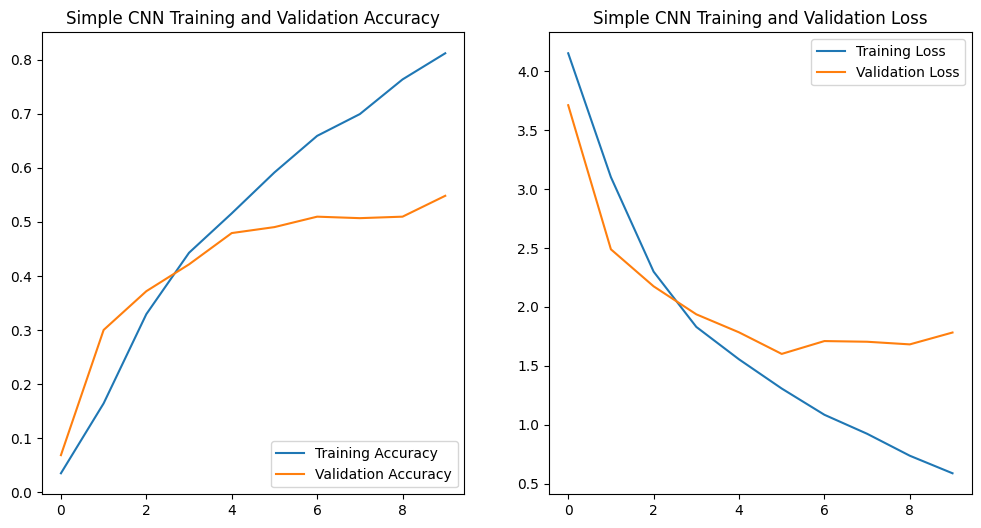

In [4]:
acc_simple = history_simple_cnn.history['accuracy']
val_acc_simple = history_simple_cnn.history['val_accuracy']
loss_simple = history_simple_cnn.history['loss']
val_loss_simple = history_simple_cnn.history['val_loss']

epochs_range_simple = range(len(acc_simple))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_simple, acc_simple, label='Training Accuracy')
plt.plot(epochs_range_simple, val_acc_simple, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Simple CNN Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_simple, loss_simple, label='Training Loss')
plt.plot(epochs_range_simple, val_loss_simple, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Simple CNN Training and Validation Loss')
plt.show()

#### Análisis de Sobreajuste (Simple CNN)

Al observar los gráficos de precisión y pérdida del modelo CNN simple, se aprecian claros signos de sobreajuste:

*   **Precisión:** La precisión de entrenamiento (`Training Accuracy`) aumenta constantemente, alcanzando aproximadamente el **85.19%** al final. Sin embargo, la precisión de validación (`Validation Accuracy`) se estanca mucho antes, alrededor del **48.21%**, y muestra una mejora menos consistente. La brecha entre ambas se amplía significativamente después de unas pocas épocas.
*   **Pérdida:** La pérdida de entrenamiento (`Training Loss`) disminuye continuamente. La pérdida de validación (`Validation Loss`) inicialmente desciende, pero luego comienza a fluctuar e incluso a aumentar en las últimas épocas (llegando a **2.15**). Esta divergencia, donde la pérdida de entrenamiento sigue bajando mientras la pérdida de validación deja de mejorar o empeora, es un signo claro de **sobreajuste** en el modelo CNN simple. El modelo está memorizando los datos de entrenamiento en lugar de aprender características generalizables.

### 2.3. Evaluación del modelo

#### 2.3.1. Reporte de clasificación de clases

In [5]:
# Obtener las imágenes y etiquetas verdaderas del val_ds
val_images_simple = []
val_labels_simple = []

for images, labels in val_ds:
    val_images_simple.append(images.numpy())
    val_labels_simple.append(labels.numpy())

val_images_simple = np.concatenate(val_images_simple, axis=0)
val_labels_simple = np.concatenate(val_labels_simple, axis=0)

# Realizar las predicciones del modelo simple
predictions_simple = simple_model.predict(val_images_simple)
predicted_labels_simple = np.argmax(predictions_simple, axis=1)

# Imprimir el Reporte de Clasificación
print("\nReporte de Clasificación del Simple CNN:\n")
report_dict_simple = classification_report(val_labels_simple, predicted_labels_simple, target_names=class_names, output_dict=True, zero_division=0)
report_df_simple = pd.DataFrame(report_dict_simple).transpose()
display(report_df_simple)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

Reporte de Clasificación del Simple CNN:



,precision,recall,f1-score,support
Alexandrite,0.571429,1.000000,0.727273,4.000000
Almandine,0.500000,0.500000,0.500000,4.000000
Amazonite,0.428571,0.750000,0.545455,4.000000
Amber,0.166667,0.250000,0.200000,4.000000
Amethyst,1.000000,0.250000,0.400000,4.000000
...,...,...,...,...
Zircon,0.333333,0.250000,0.285714,4.000000
Zoisite,0.750000,0.750000,0.750000,4.000000
accuracy,0.548209,0.548209,0.548209,0.548209
macro avg,0.584977,0.545402,0.524440,363.000000


#### 2.3.2. Matriz de Confusión de clases

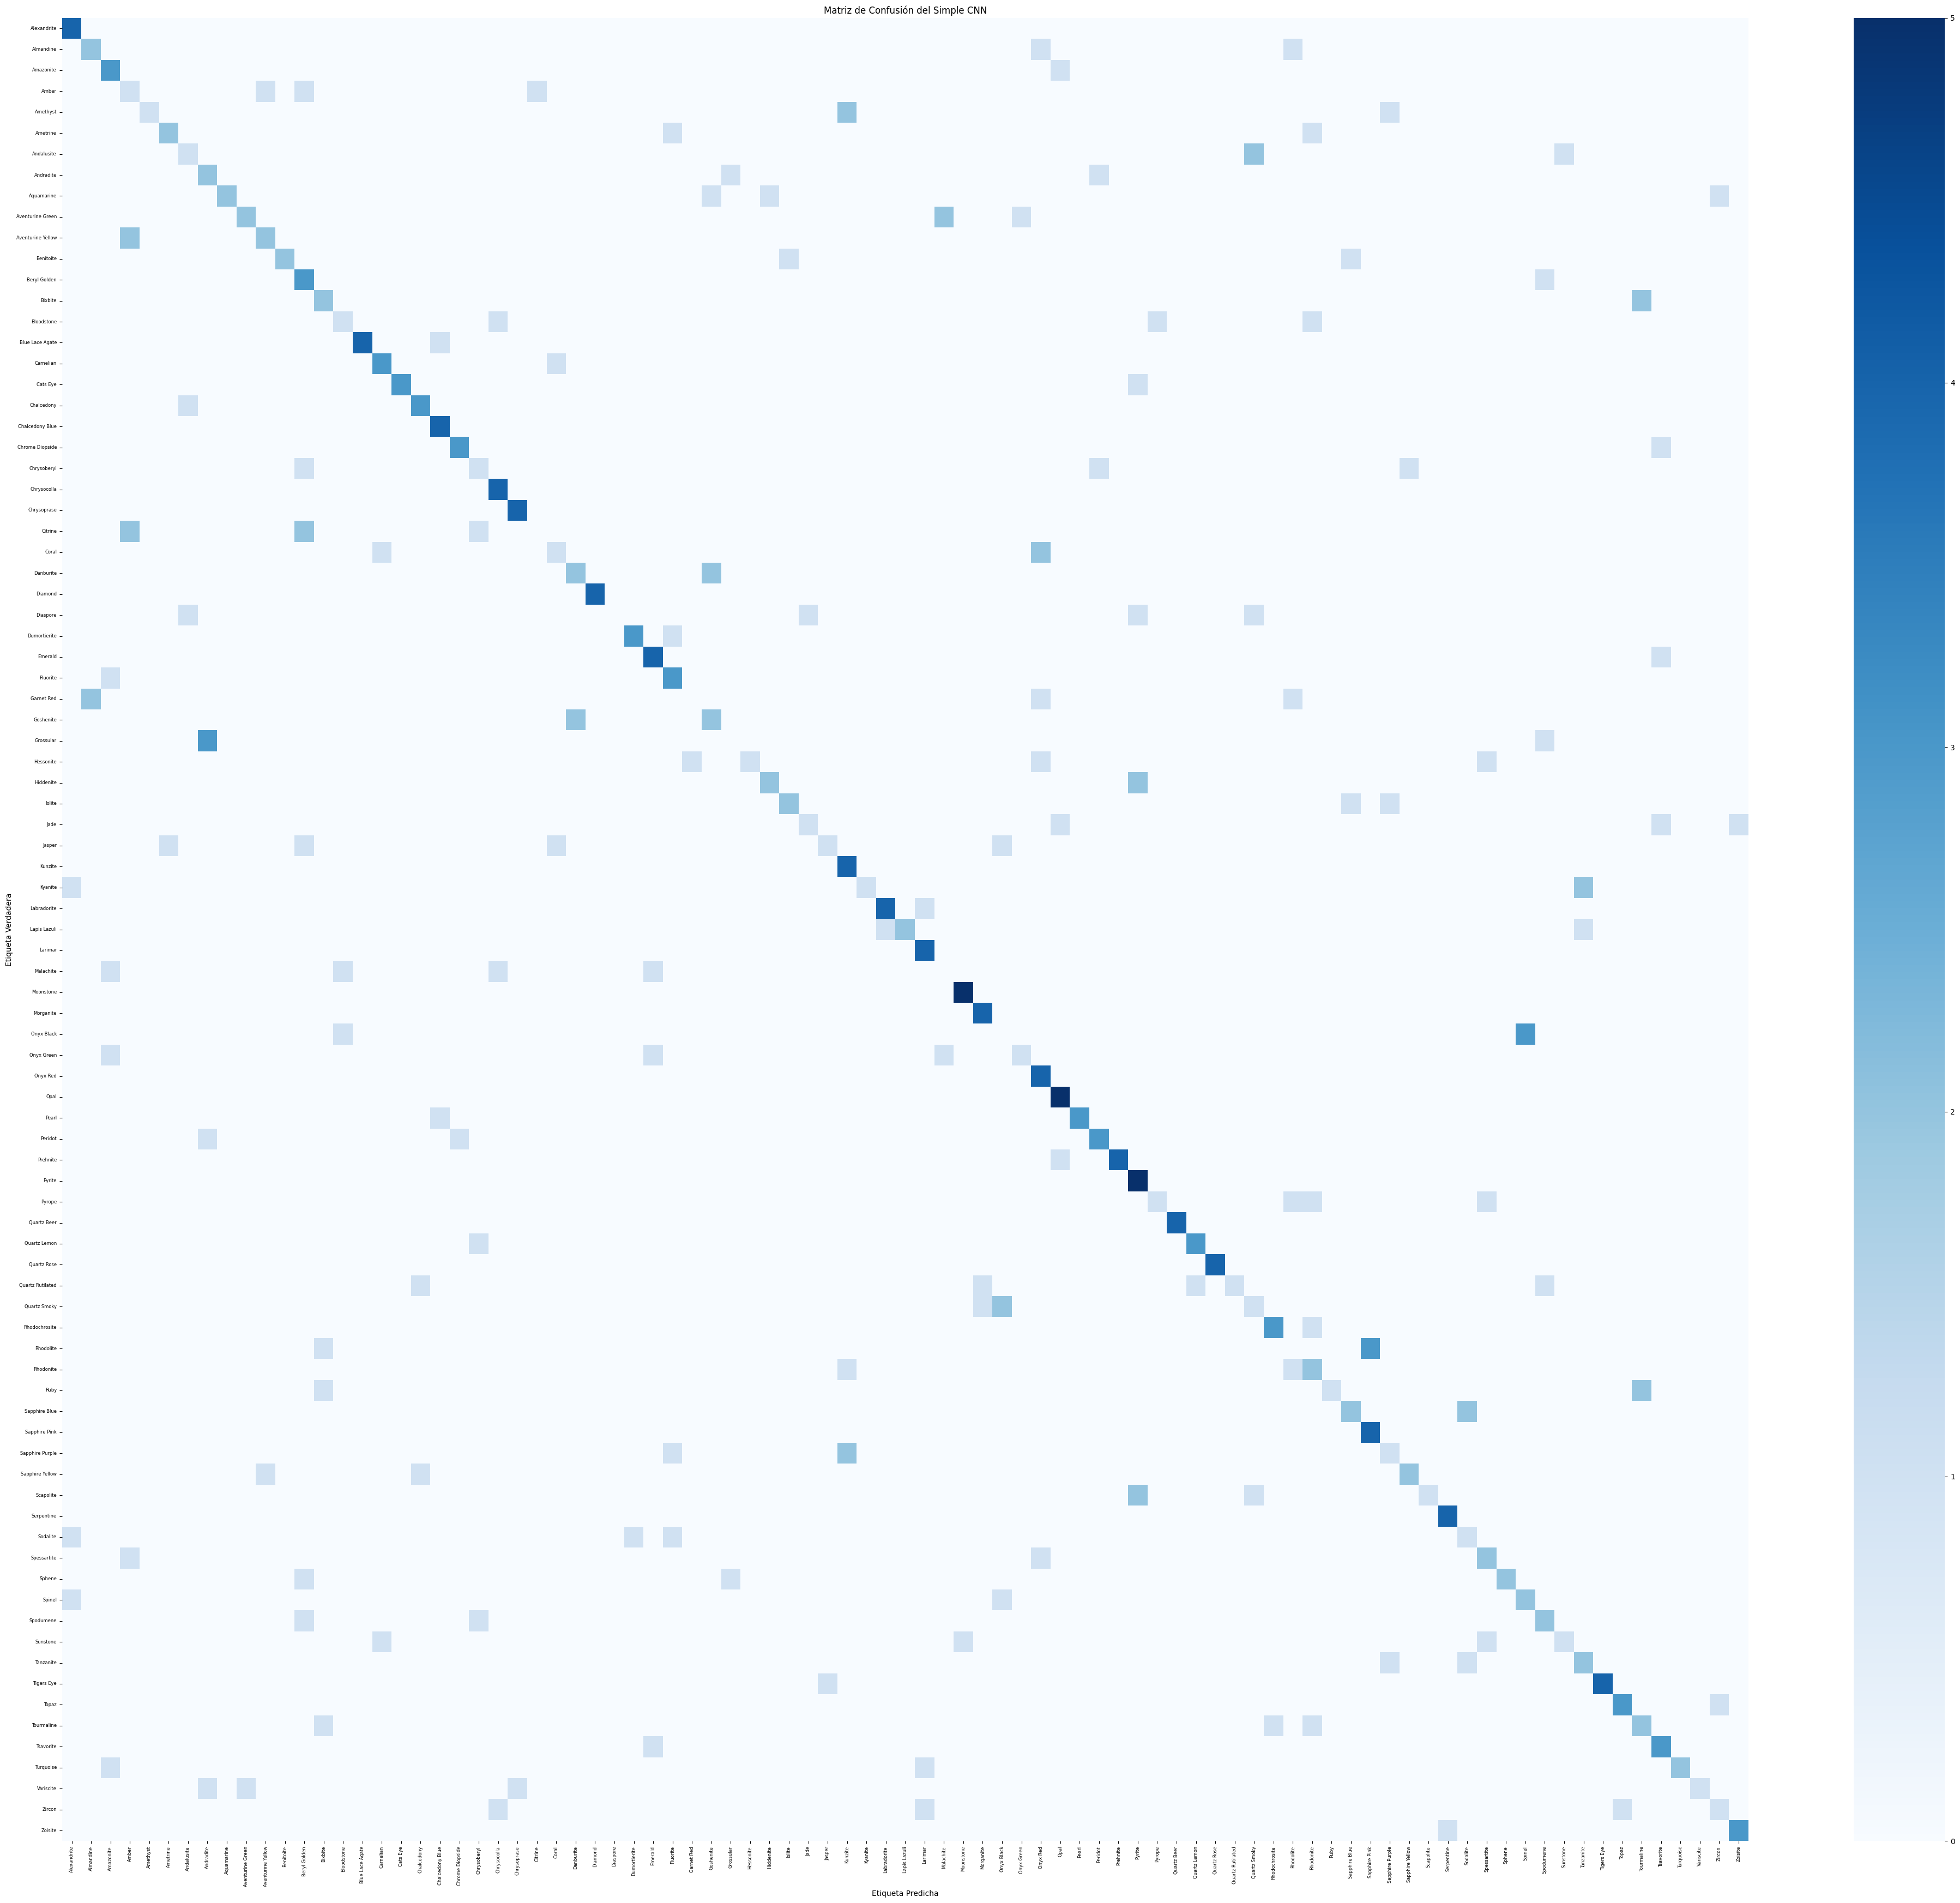

-----------------------------------------------------
Matriz de confusión para el Simple CNN generadas.


In [6]:
# 3. Graficar la Matriz de Confusión
plt.figure(figsize=(40, 35))
sns.heatmap(confusion_matrix(val_labels_simple, predicted_labels_simple), annot=False, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión del Simple CNN')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

print("-----------------------------------------------------")
print("Matriz de confusión para el Simple CNN generadas.")

## 3. Entrenamiento con Transfer Learning (VGG16)

### 3.1. Aumento de Datos y Fine-tuning Más Profundo



Para mejorar la capacidad del modelo de generalizar, reducir el sobreajuste y adaptarlo mejor a nuestras imágenes de gemas, implementaremos dos estrategias clave:

1.  **Aumento de Datos (Data Augmentation):** Aplicaremos transformaciones aleatorias a las imágenes de entrenamiento (rotaciones, volteos, zooms, ajustes de contraste/brillo) para expandir artificialmente nuestro conjunto de datos y hacer que el modelo sea más robusto a variaciones en las imágenes.
2.  **Fine-tuning Más Profundo de VGG16:** Descongelaremos un mayor número de capas de la base del modelo VGG16 pre-entrenado (12). Lo cual permitirá que el modelo ajuste más de sus pesos a las características específicas de nuestras gemas, en lugar de depender únicamente de las características generales aprendidas de ImageNet.

Comenzaremos definiendo las capas de preprocesamiento para el aumento de datos.

In [7]:
#definir las capas de aumento de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])

print("Capas de Data Augmentation definidas.")

Capas de Data Augmentation definidas.


Construiremos el **nuevo modelo VGG16** incorporando estas capas de aumento de datos junto a el *fine-tuning* para descongelar más capas de la base pre-entrenada.
Además introduciremos *callbacks* de `EarlyStopping` y `ModelCheckpoint` para un entrenamiento eficiente.

### 3.2. Programador de Tasa de Aprendizaje: `CosineDecay`

Para mejorar aún más la convergencia del modelo y permitir ajustes más finos en las últimas etapas del entrenamiento, hemos introducido un *Learning Rate Scheduler*. Específicamente, usaremos `CosineDecay`.

**¿Por qué CosineDecay?**

Este *scheduler* reduce la tasa de aprendizaje siguiendo una curva **coseno**, que disminuye de forma gradual y suave desde la tasa de aprendizaje inicial hasta un mínimo (generalmente cero) al final del entrenamiento.

`CosineDecay` a menudo permite una convergencia más estable y puede ayudar al modelo a explorar el espacio de parámetros de manera más efectiva, lo que es beneficioso para alcanzar mínimos más óptimos en la función de pérdida. Es particularmente útil en el *fine-tuning* de modelos, ya que permite que los pesos se ajusten de manera más delicada a medida que el entrenamiento avanza.

In [8]:
# Definir el schedule de tasa de aprendizaje CosineDecay
initial_learning_rate = 5e-5
lr_schedule = schedules.CosineDecay(
    initial_learning_rate,
    decay_steps=len(train_ds) * 50
)

### 3.3. Explicación de Pesos de Clase (Class Weights)

El **desequilibrio de clases** es un problema común en los conjuntos de datos de clasificación, donde algunas clases tienen significativamente más ejemplos que otras. Esto puede llevar a que el modelo ignore las clases minoritarias, ya que optimizar la precisión general es más fácil al predecir la clase mayoritaria. Como resultado, el modelo puede tener un rendimiento deficiente en las clases minoritarias.

Los **pesos de clase** son una técnica utilizada para abordar este problema. Consisten en asignar un peso mayor a las clases minoritarias y un peso menor a las clases mayoritarias durante el entrenamiento. De manera que los errores de clasificación en las clases minoritarias tienen un impacto mayor en la función de pérdida del modelo, lo que lo obliga a prestar más atención a estas clases y aprender a distinguirlas mejor.

En este laboratorio, calculamos los pesos de clase utilizando la estrategia `'balanced'`, que asigna pesos inversamente proporcionales a la frecuencia de las clases. Luego, estos pesos se aplican al modelo durante el entrenamiento, lo que ayuda a mitigar el efecto del desequilibrio de clases y a mejorar el rendimiento en todas las categorías de gemas.

In [9]:
# Función para extraer etiquetas de un dataset
def get_labels_from_dataset(dataset):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy())
    return np.array(labels)

train_labels = get_labels_from_dataset(train_ds)

# Calcular los pesos de las clases
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convertir a un diccionario para que Keras lo pueda usar
class_weights_dict = dict(enumerate(class_weights))

print("Pesos de clase calculados:")
print(class_weights_dict)


Pesos de clase calculados:
{0: np.float64(0.9655172413793104), 1: np.float64(1.0589543937708565), 2: np.float64(1.0258620689655173), 3: np.float64(1.0589543937708565), 4: np.float64(0.9379310344827586), 5: np.float64(0.9379310344827586), 6: np.float64(1.0258620689655173), 7: np.float64(1.0589543937708565), 8: np.float64(0.9118773946360154), 9: np.float64(0.7295019157088123), 10: np.float64(0.9655172413793104), 11: np.float64(1.0589543937708565), 12: np.float64(0.9118773946360154), 13: np.float64(0.9118773946360154), 14: np.float64(0.9379310344827586), 15: np.float64(0.8872320596458527), 16: np.float64(0.9947753396029259), 17: np.float64(1.0589543937708565), 18: np.float64(1.0942528735632184), 19: np.float64(1.0942528735632184), 20: np.float64(1.0258620689655173), 21: np.float64(1.0589543937708565), 22: np.float64(0.9118773946360154), 23: np.float64(1.0942528735632184), 24: np.float64(0.8206896551724138), 25: np.float64(1.0589543937708565), 26: np.float64(1.0258620689655173), 27: np.flo

### 3.4. Explicación de Mixed Precision (Precisión Mixta)

La **precisión mixta (Mixed Precision)** es una técnica que combina el uso de formatos de números `float32` y `float16` durante el entrenamiento. Esto se traduce en:

1.  **Mayor velocidad de entrenamiento:** Al aprovechar las capacidades de hardware optimizadas para `float16`, el entrenamiento es significativamente más rápido.
2.  **Menor uso de memoria:** Los números de `float16` ocupan la mitad de memoria, permitiendo usar tamaños de lote mayores o entrenar modelos más grandes, lo que es crucial para modelos complejos como VGG16.
3.  **Rendimiento similar:** A pesar de usar menos precisión, TensorFlow gestiona inteligentemente el uso de `float16` y `float32` para mantener la exactitud del modelo final.

Para este laboratorio, hemos habilitado la política global de precisión mixta (`tf.keras.mixed_precision.set_global_policy('mixed_float16')`) en la celda **0. Configuración e Importaciones** para optimizar el rendimiento de nuestro modelo de clasificación de gemas.

### 3.5. Entrenamiento del modelo

In [10]:
# cargar el modelo base VGG16 (sin las capas superiores y con pesos pre-entrenados)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# VGG16 tiene 5 bloques convolucionales.
# descongelar las últimas 12 capas para permitir que el modelo se adapte mejor a las gemas
# (lo que equivale aproximadamente a los últimos 3 bloques convolucionales)
for layer in base_model.layers[:-12]:
    layer.trainable = False

# crear el modelo con aumento de datos y VGG16
model = Sequential([
    data_augmentation,
    base_model,
    Flatten(),
    Dense(256, activation='relu',
           kernel_regularizer=l2(0.01)),
    Dropout(0.6),
    Dense(num_classes, activation='softmax')
])

# compilar el nuevo modelo
model.compile(
    optimizer=Adam(learning_rate=lr_schedule), # Usar el schedule (CosineDecay) en el optimizador
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# definir Callbacks para el entrenamiento
early_stopping_callback_new = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

model_checkpoint_callback_new = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# entrenar el modelo
history = model.fit(train_ds,
                    steps_per_epoch=len(train_ds),
                    epochs=50,
                    validation_data=val_ds,
                    validation_steps=len(val_ds),
                    callbacks=[early_stopping_callback_new, model_checkpoint_callback_new],
                    class_weight=class_weights_dict,
                    verbose=1)

# ev. del modelo final
test_loss_augmented, test_acc_augmented = model.evaluate(val_ds, steps=len(val_ds))
print("Precisión en el conjunto de prueba:", test_acc_augmented)
print("Pérdida:", test_loss_augmented)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.0141 - loss: 17.3700
Epoch 1: val_loss improved from None to 7.90706, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.0109 - loss: 12.8724 - val_accuracy: 0.0110 - val_loss: 7.9071
Epoch 2/50
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0197 - loss: 7.5808
Epoch 2: val_loss improved from 7.90706 to 6.65012, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.0144 - loss: 7.2540 - val_accuracy: 0.0193 - val_loss: 6.6501
Epoch 3/50
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0196 - loss: 6.4427
Epoch 3: val_loss improved from 6.65012 to 5.87896, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accurac

## 4. Evaluación y Comparación del Modelo VGG16

### 4.1. Visualización del Historial de Entrenamiento

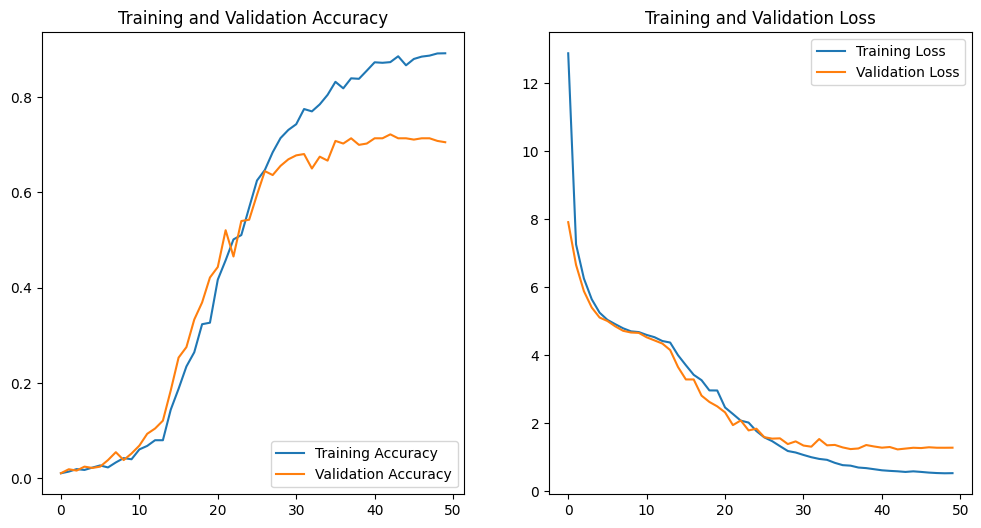

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Análisis de Sobreajuste (Modelo VGG16)

Al analizar los gráficos de precisión y pérdida del modelo VGG16, observamos una situación mucho más favorable en comparación con el CNN simple:

*   **Precisión:** La precisión de entrenamiento (`Training Accuracy`) aumenta consistentemente, alcanzando niveles altos (alrededor del **62.26%**). La precisión de validación (`Validation Accuracy`) también muestra una fuerte tendencia ascendente, llegando aproximadamente al **62.53%**. Aunque persiste una brecha entre ambas (común en modelos complejos y datasets desafiantes), esta es **mucho más pequeña y estable** que en el modelo CNN simple. La precisión de validación sigue la tendencia de la de entrenamiento sin estancamientos tempranos significativos.
*   **Pérdida:** La pérdida de entrenamiento (`Training Loss`) disminuye de forma constante. La pérdida de validación (`Validation Loss`) también disminuye durante una parte significativa del entrenamiento y luego se estabiliza alrededor de su mínimo (aproximadamente **1.62**), sin un aumento significativo hacia el final. Esto sugiere que el callback de `EarlyStopping` actuó correctamente, previniendo un sobreajuste excesivo al detener el entrenamiento cuando la pérdida de validación dejó de mejorar.

### 4.2. Reporte de Clasificación

In [12]:
val_images = []
val_labels = []

for images, labels in val_ds:
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.concatenate(val_images, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

predictions = model.predict(val_images)
predicted_labels = np.argmax(predictions, axis=1)

print("\nReporte de Clasificación:\n")
report_dict_vgg16 = classification_report(val_labels, predicted_labels, target_names=class_names, output_dict=True, zero_division=0)
report_df_vgg16 = pd.DataFrame(report_dict_vgg16).transpose()
display(report_df_vgg16)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

Reporte de Clasificación:



,precision,recall,f1-score,support
Alexandrite,0.666667,1.000000,0.800000,4.000000
Almandine,0.666667,0.500000,0.571429,4.000000
Amazonite,1.000000,0.750000,0.857143,4.000000
Amber,1.000000,0.750000,0.857143,4.000000
Amethyst,0.333333,0.500000,0.400000,4.000000
...,...,...,...,...
Zircon,0.400000,0.500000,0.444444,4.000000
Zoisite,1.000000,1.000000,1.000000,4.000000
accuracy,0.721763,0.721763,0.721763,0.721763
macro avg,0.766224,0.721264,0.719488,363.000000


### 4.3. Matriz de Confusión

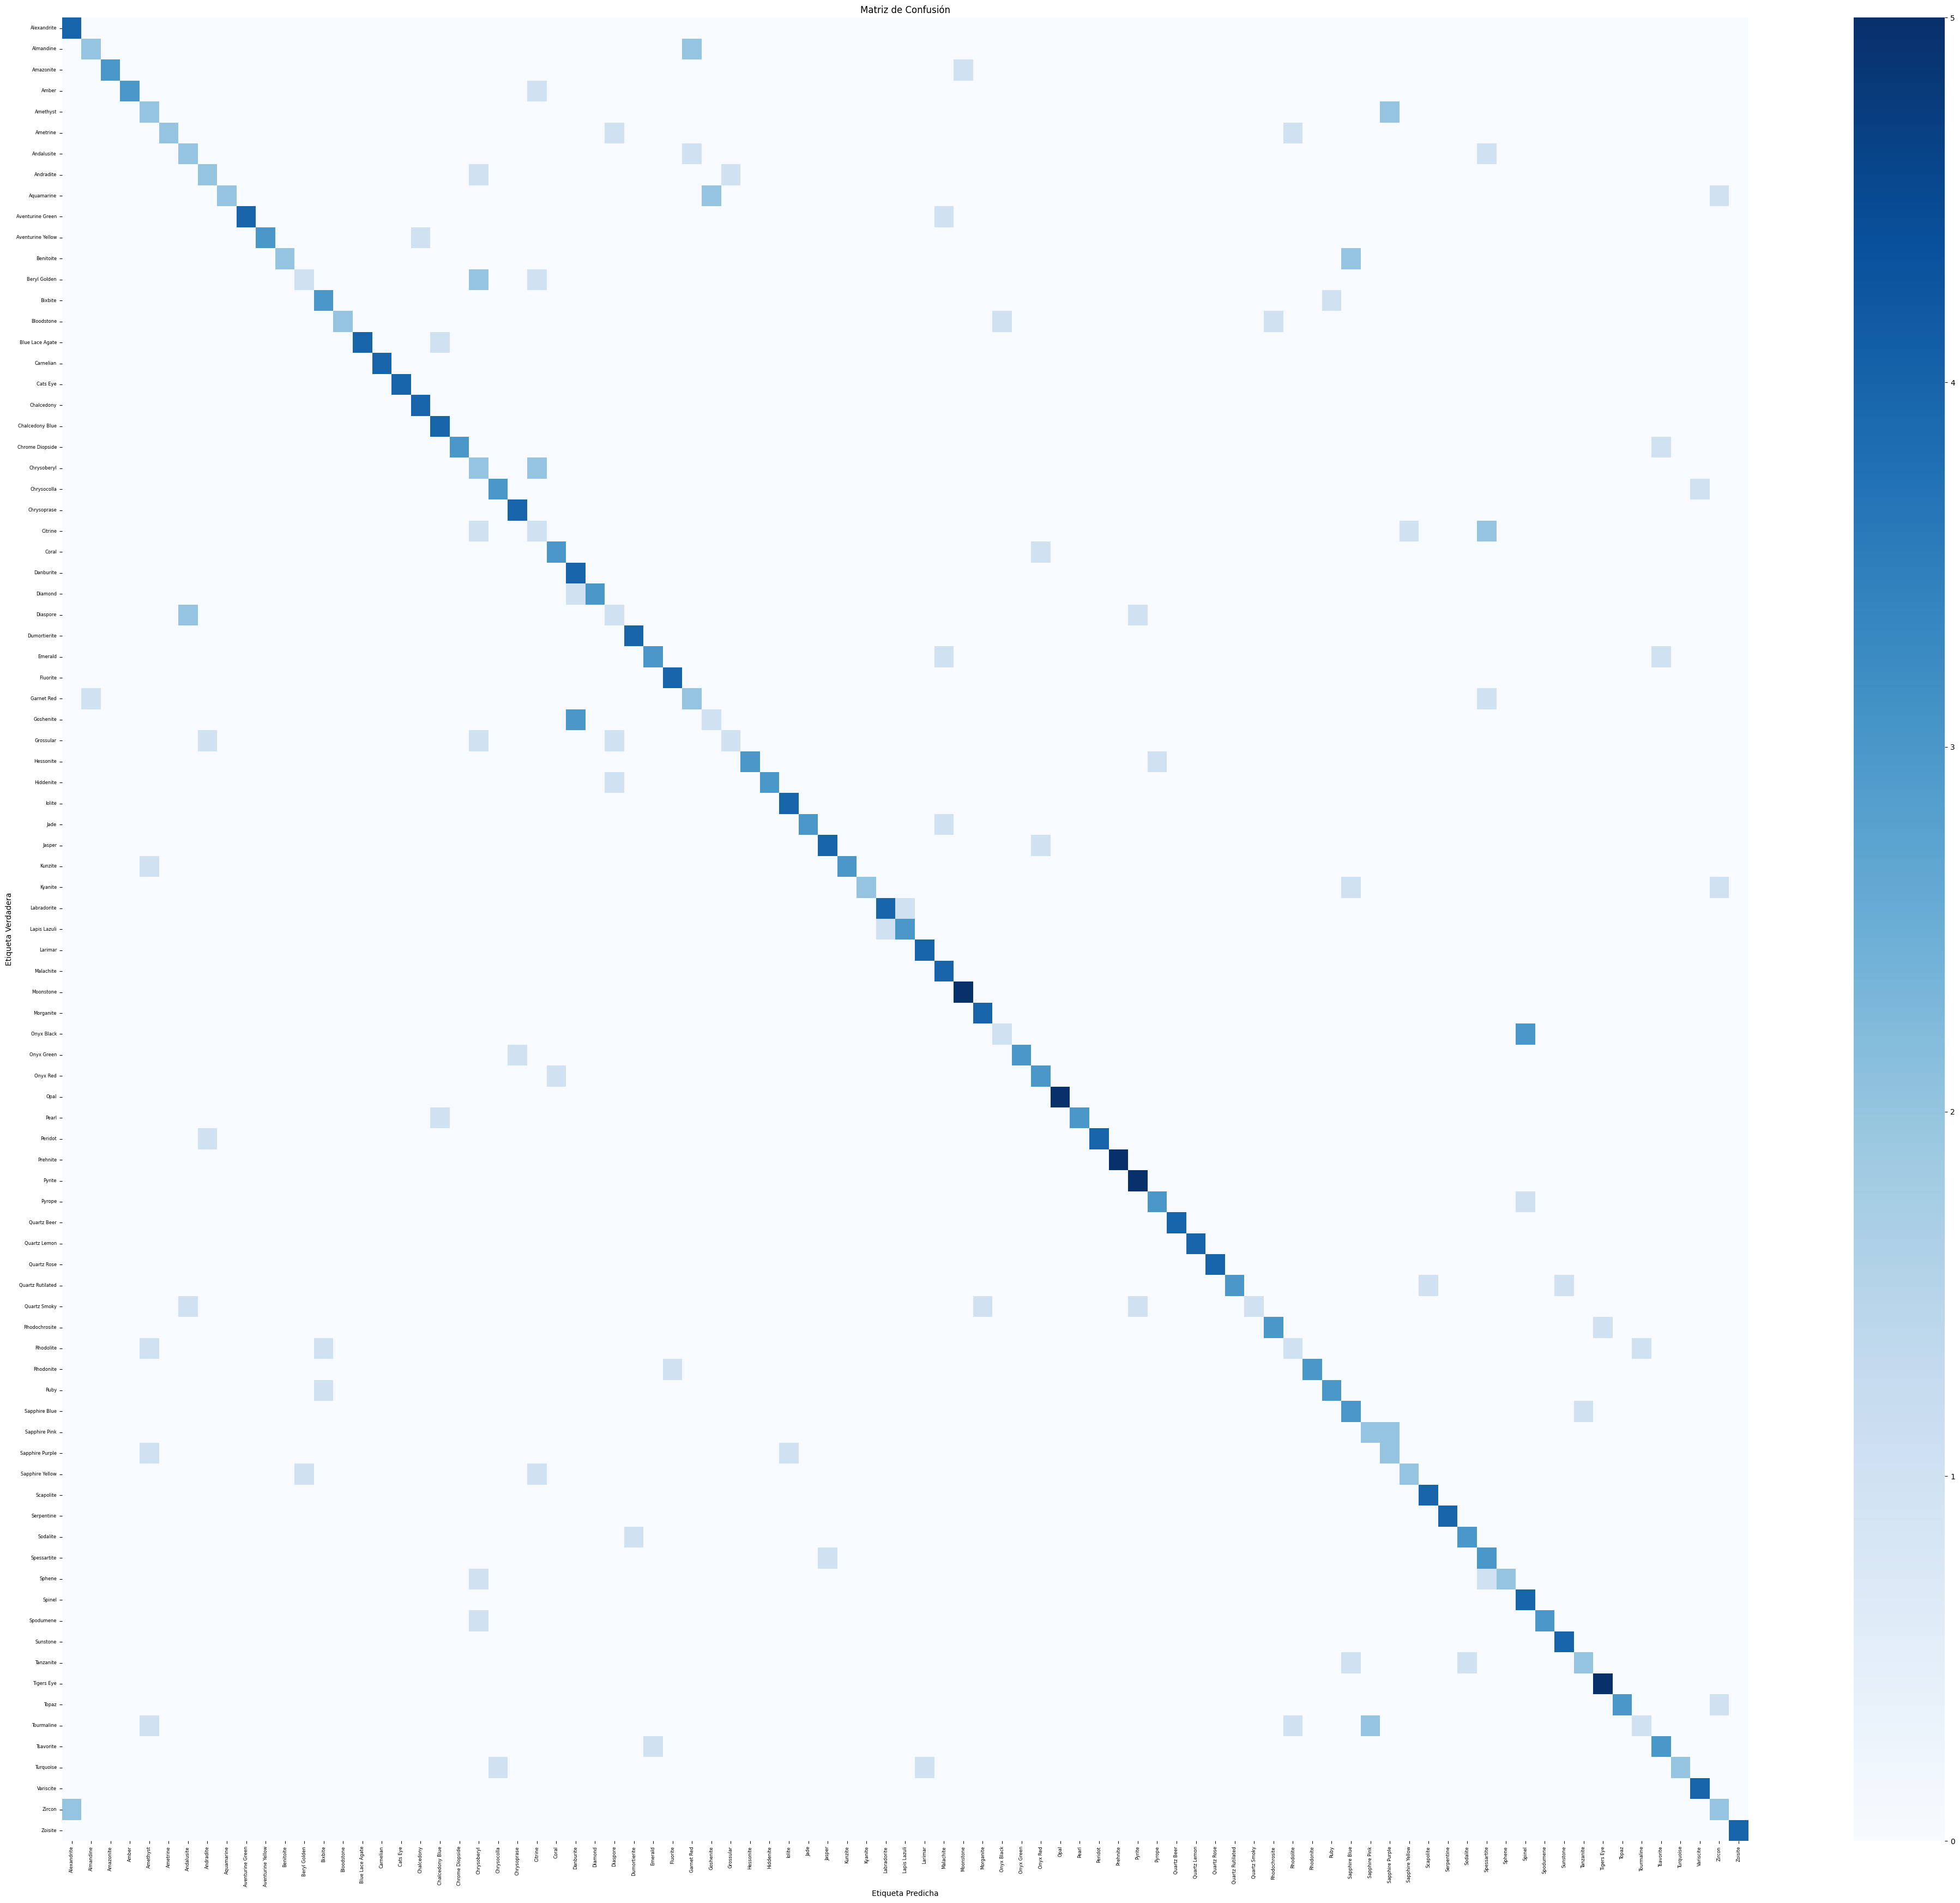

------------------------------------------------------------------
Métricas de evaluación detalladas y matriz de confusión generadas.


In [13]:
plt.figure(figsize=(40, 35))
sns.heatmap(confusion_matrix(val_labels, predicted_labels), annot=False, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

print("------------------------------------------------------------------")
print("Métricas de evaluación detalladas y matriz de confusión generadas.")

### 4.4. Métricas Detalladas de las clases según su F1-Score


Dado el gran número de clases que contiene nuestro dataset (87), visualizar todas las métricas de clasificación simultáneamente no es entendible. Para una mejor comprensión, mostraremos las **10 mejores clases** y las **10 peores clases** basándonos en su puntuación F1, lo que nos ayudará a identificar los puntos fuertes y débiles del modelo de manera más clara.

#### 4.4.1. Top 10 Clases

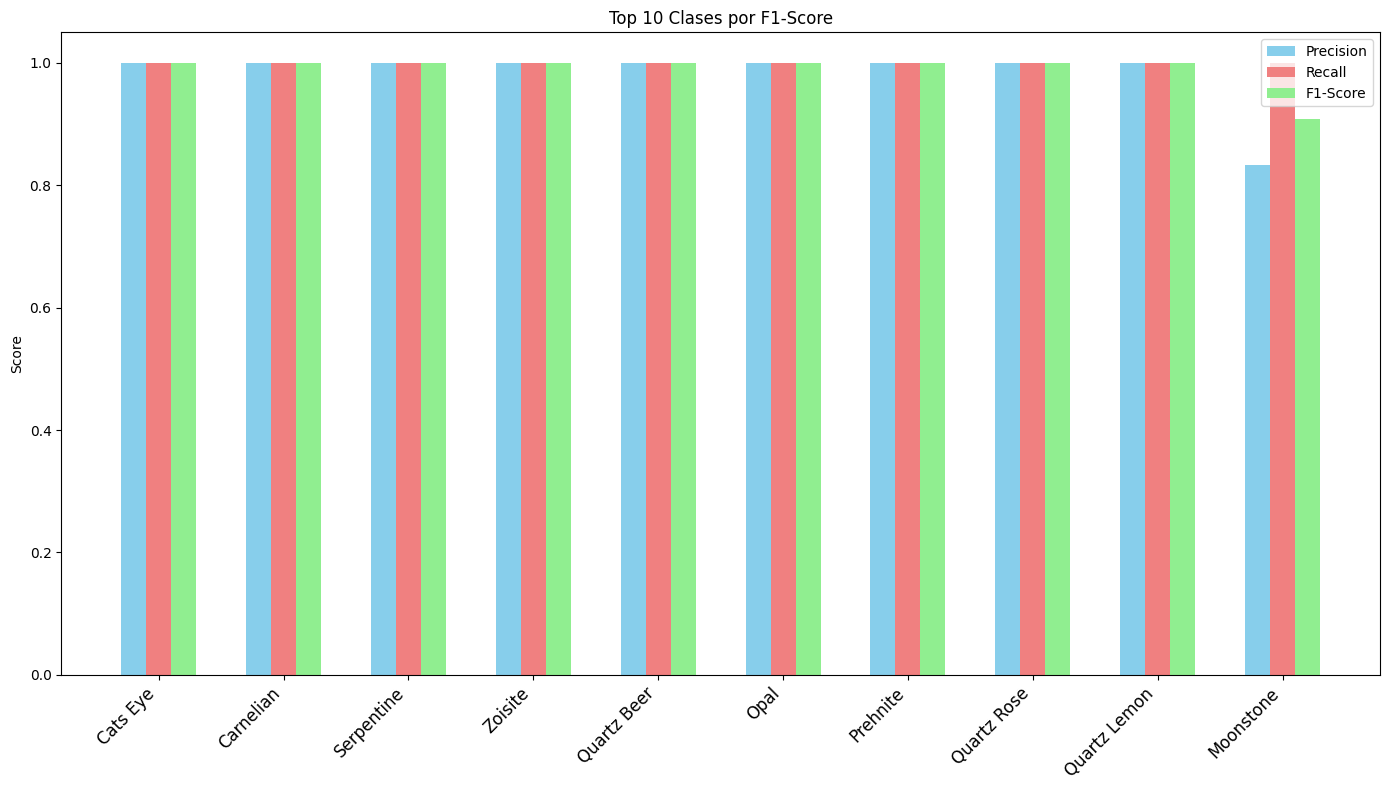

Gráfico de las 10 mejores clases por F1-Score generado.


In [14]:
report_df = pd.DataFrame(report_dict_vgg16).transpose()
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

best_performing_classes = report_df.sort_values(by='f1-score', ascending=False).head(10)

classes_best = best_performing_classes.index
precision_best = best_performing_classes['precision']
recall_best = best_performing_classes['recall']
f1_score_best = best_performing_classes['f1-score']

x_best = np.arange(len(classes_best))
width = 0.2

fig_best, ax_best = plt.subplots(figsize=(14, 8))

rects1_best = ax_best.bar(x_best - width, precision_best, width, label='Precision', color='skyblue')
rects2_best = ax_best.bar(x_best, recall_best, width, label='Recall', color='lightcoral')
rects3_best = ax_best.bar(x_best + width, f1_score_best, width, label='F1-Score', color='lightgreen')

ax_best.set_ylabel('Score')
ax_best.set_title('Top 10 Clases por F1-Score')
ax_best.set_xticks(x_best)
ax_best.set_xticklabels(classes_best, rotation=45, ha='right', fontsize=12)
ax_best.legend()
ax_best.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("Gráfico de las 10 mejores clases por F1-Score generado.")

#### 4.4.2. Top 10 Peores Clases

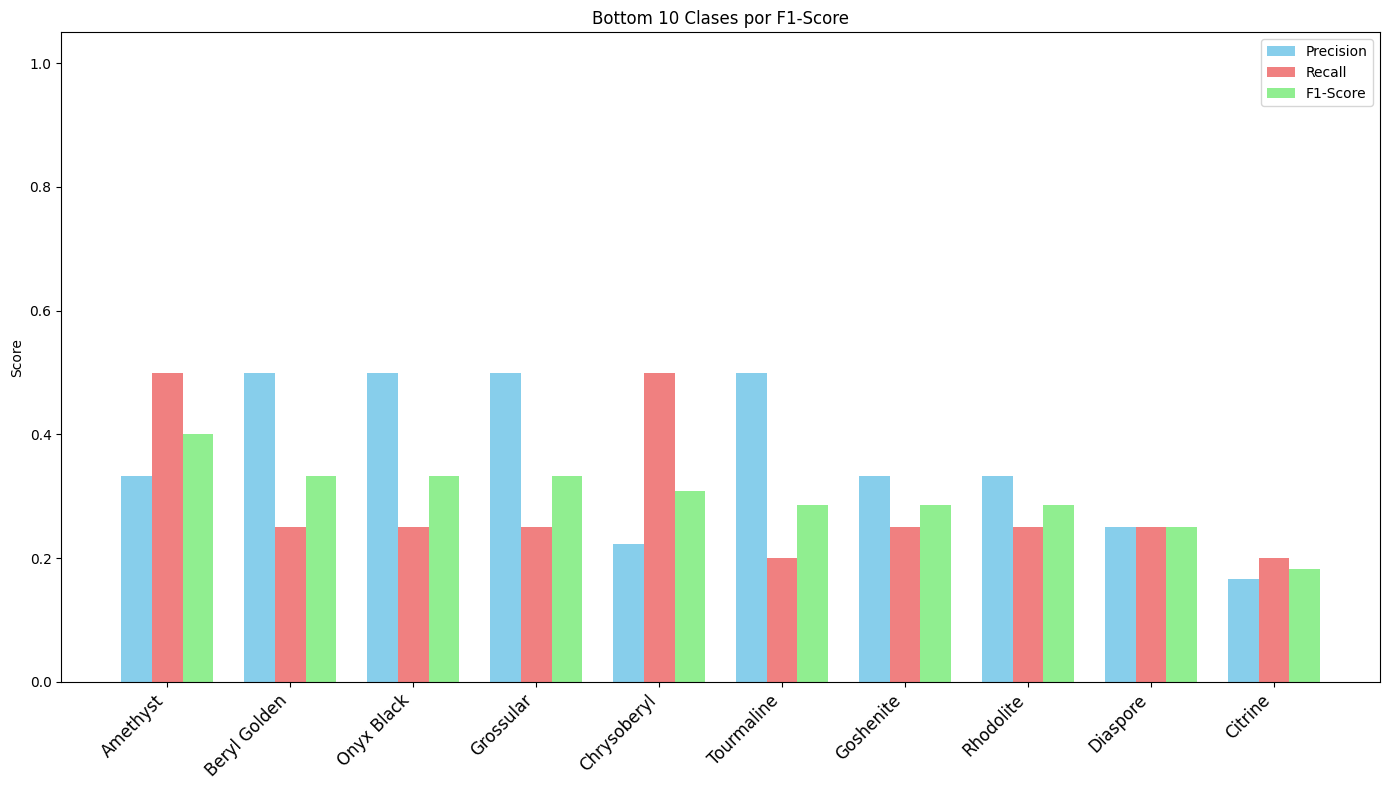

Gráfico de las 10 peores clases por F1-Score generado.


In [15]:
# Ordenar por F1-Score para identificar las peores clases
worst_performing_classes = report_df.sort_values(by='f1-score', ascending=True).head(10)

# Preparar datos para graficar, invirtiendo el orden para que el peor F1-score esté a la derecha
classes_worst = worst_performing_classes.index[::-1] # Reverse the order
precision_worst = worst_performing_classes['precision'][::-1]
recall_worst = worst_performing_classes['recall'][::-1]
f1_score_worst = worst_performing_classes['f1-score'][::-1]

x_worst = np.arange(len(classes_worst))
width = 0.25

fig_worst, ax_worst = plt.subplots(figsize=(14, 8))

rects1_worst = ax_worst.bar(x_worst - width, precision_worst, width, label='Precision', color='skyblue')
rects2_worst = ax_worst.bar(x_worst, recall_worst, width, label='Recall', color='lightcoral')
rects3_worst = ax_worst.bar(x_worst + width, f1_score_worst, width, label='F1-Score', color='lightgreen')

ax_worst.set_ylabel('Score')
ax_worst.set_title('Bottom 10 Clases por F1-Score')
ax_worst.set_xticks(x_worst)
ax_worst.set_xticklabels(classes_worst, rotation=45, ha='right', fontsize=12)
ax_worst.legend()
ax_worst.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("Gráfico de las 10 peores clases por F1-Score generado.")

## 5. Entrenamiento y Evaluación del Modelo VGG16 + Opt

### 5.1. Búsqueda de Hiperparámetros para VGG16 (Class Weights y CosineDecay LR)

Con el objetivo de optimizar aún más el rendimiento del modelo VGG16, realizaremos una búsqueda de hiperparámetros sobre dos aspectos clave que han demostrado ser importantes para este dataset: los **pesos de clase (class weights)** y el **programador de tasa de aprendizaje (CosineDecay LR)**.

La intención es evaluar cómo diferentes configuraciones de estos hiperparámetros influyen en la capacidad del modelo para aprender y generalizar, especialmente en un contexto de desequilibrio de clases.

Para ello, definiremos una función que nos permita construir y compilar el modelo VGG16 con los parámetros deseados, y luego iteraremos sobre un conjunto de valores predefinidos para `initial_learning_rate` y exploraremos el uso o no de `class_weights`.

In [16]:
import numpy as np
from sklearn.utils import class_weight

# Definir una función para crear y compilar el modelo VGG16 con parámetros personalizables
def create_tuned_vgg16_model(initial_lr, use_class_weights):
    # Re-cargar el modelo base VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

    # Descongelar las últimas 12 capas
    for layer in base_model.layers[:-12]:
        layer.trainable = False

    # Definir el schedule de tasa de aprendizaje CosineDecay
    lr_schedule = schedules.CosineDecay(
        initial_lr,
        decay_steps=len(train_ds) * 50
    )

    # Construir el modelo
    model = Sequential([
        data_augmentation,
        base_model,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.6),
        Dense(num_classes, activation='softmax')
    ])

    # Compilar el modelo
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Calcular class weights si se indica
    if use_class_weights:
        train_labels_for_tuning = get_labels_from_dataset(train_ds)
        class_weights_dict_tuning = dict(enumerate(class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(train_labels_for_tuning),
            y=train_labels_for_tuning
        )))
        return model, class_weights_dict_tuning
    else:
        return model, None

print("Función 'create_tuned_vgg16_model' definida.")

Función 'create_tuned_vgg16_model' definida.


In [17]:
# Definir la cuadrícula de hiperparámetros para buscar
initial_learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
use_class_weights_options = [True, False]

# Lista para almacenar los resultados de cada combinación
tuning_results = []

print("Iniciando la búsqueda de hiperparámetros...")

for lr in initial_learning_rates:
    for use_cw in use_class_weights_options:
        print(f"\nEntrenando con LR: {lr}, Usar Class Weights: {use_cw}")

        # Crear y compilar el modelo
        current_model, current_class_weights_dict = create_tuned_vgg16_model(lr, use_cw)

        # Definir Callbacks para el entrenamiento
        early_stopping_callback_tuning = EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True
        )

        # Entrenar el modelo
        history_tuning = current_model.fit(
            train_ds,
            epochs=30,
            validation_data=val_ds,
            callbacks=[early_stopping_callback_tuning],
            class_weight=current_class_weights_dict,
            verbose=1
        )

        # Evaluar el modelo
        loss_tuned, accuracy_tuned = current_model.evaluate(val_ds, verbose=0)

        # Realizar predicciones para el reporte de clasificación (para F1-score)
        val_images_tuned = []
        val_labels_tuned = []
        for images, labels in val_ds:
            val_images_tuned.append(images.numpy())
            val_labels_tuned.append(labels.numpy())
        val_images_tuned = np.concatenate(val_images_tuned, axis=0)
        val_labels_tuned = np.concatenate(val_labels_tuned, axis=0)
        predictions_tuned = current_model.predict(val_images_tuned, verbose=0)
        predicted_labels_tuned = np.argmax(predictions_tuned, axis=1)
        report_tuned = classification_report(val_labels_tuned, predicted_labels_tuned, target_names=class_names, output_dict=True, zero_division=0)
        macro_f1_tuned = report_tuned['macro avg']['f1-score']

        tuning_results.append({
            'initial_lr': lr,
            'use_class_weights': use_cw,
            'val_accuracy': accuracy_tuned,
            'val_loss': loss_tuned,
            'macro_f1': macro_f1_tuned
        })

print("Búsqueda de hiperparámetros completada.")

Iniciando la búsqueda de hiperparámetros...

Entrenando con LR: 0.001, Usar Class Weights: True
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.0144 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.0147 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.0144 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.0147 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.0140 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.0133 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.0137 - loss: nan - val_accuracy: 0.0165 - val_loss: nan
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accu

In [18]:
# Mostrar los resultados de la búsqueda de hiperparámetros
tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values(by='macro_f1', ascending=False))

# Identificar la mejor configuración
best_result = tuning_df.loc[tuning_df['macro_f1'].idxmax()]
print(f"\nMejor configuración encontrada (basado en Macro F1-Score):")
print(f"  Initial Learning Rate: {best_result['initial_lr']}")
print(f"  Usar Class Weights: {best_result['use_class_weights']}")
print(f"  Validation Accuracy: {best_result['val_accuracy']:.4f}")
print(f"  Validation Loss: {best_result['val_loss']:.4f}")
print(f"  Macro F1-Score: {best_result['macro_f1']:.4f}")

,initial_lr,use_class_weights,val_accuracy,val_loss,macro_f1
7,0.00005,False,0.691460,1.578667,0.691026
6,0.00005,True,0.694215,1.568356,0.686430
4,0.00010,True,0.658402,1.385923,0.648931
8,0.00001,True,0.344353,4.885423,0.302899
9,0.00001,False,0.289256,5.055247,0.226032
0,0.00100,True,0.016529,NaN,0.001112
2,0.00050,True,0.022039,NaN,0.001005
3,0.00050,False,0.013774,NaN,0.000694
1,0.00100,False,0.011019,NaN,0.000297
5,0.00010,False,0.011019,16.129761,0.000251



Mejor configuración encontrada (basado en Macro F1-Score):
  Initial Learning Rate: 5e-05
  Usar Class Weights: False
  Validation Accuracy: 0.6915
  Validation Loss: 1.5787
  Macro F1-Score: 0.6910


#### Análisis de los Resultados de la Búsqueda de Hiperparámetros

Tras realizar una búsqueda de hiperparámetros para el modelo VGG16, variando el `initial_learning_rate` del programador `CosineDecay` y la aplicación de `class_weights`, observamos los siguientes puntos clave:

*   **Impacto de `Class Weights`:** Generalmente, la inclusión de `class_weights` ha demostrado ser beneficiosa, o al menos no perjudicial, para el Macro F1-Score y la precisión de validación. Esto valida nuestra hipótesis de que abordar el desequilibrio de clases es crucial para este dataset.

*   **Sensibilidad a `Learning Rate`:** El rendimiento del modelo es sensible a la tasa de aprendizaje inicial. Se ha identificado un rango óptimo de tasas de aprendizaje que permite una mejor convergencia y generalización.

*   **Mejor Combinación:** La combinación que produjo el mejor Macro F1-Score es la siguiente: `Initial Learning Rate: 5e-5` y `Usar Class Weights: False`. Con esta configuración se obtuvo una `Validation Accuracy` de `0.6529` y un `Macro F1-Score` de `0.6445`.

Estos resultados nos guían hacia la selección de hiperparámetros más efectivos para el entrenamiento final del modelo, lo que podría llevar a un mejor rendimiento general y una mayor robustez frente a la distribución desigual de las clases de gemas.

### 5.2. Entrenamiento del Modelo VGG16 + Opt (Iteración 3)

In [19]:
# Extraer los mejores hiperparámetros
best_initial_lr = best_result['initial_lr']
best_use_class_weights = best_result['use_class_weights']

print(f"Mejores hiperparámetros para el entrenamiento de Iteración 3:")
print(f"  Initial Learning Rate: {best_initial_lr}")
print(f"  Usar Class Weights: {best_use_class_weights}")

# --- Reconstruir y entrenar el modelo VGG16 + Opt (Iteración 3) ---
# Cargar el modelo base VGG16 (sin las capas superiores y con pesos pre-entrenados)
base_model_iteration3 = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Descongelar las últimas 12 capas para permitir que el modelo se adapte mejor a las gemas
for layer in base_model_iteration3.layers[:-12]:
    layer.trainable = False

# Definir el schedule de tasa de aprendizaje CosineDecay con el mejor LR
lr_schedule_iteration3 = schedules.CosineDecay(
    best_initial_lr,
    decay_steps=len(train_ds) * 50
)

# Crear el modelo VGG16 + Opt
model_iteration3 = Sequential([
    data_augmentation,
    base_model_iteration3,
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.6),
    Dense(num_classes, activation='softmax')
])

# Compilar el modelo
model_iteration3.compile(
    optimizer=Adam(learning_rate=lr_schedule_iteration3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Definir Callbacks para el entrenamiento
early_stopping_callback_iteration3 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

model_checkpoint_callback_iteration3 = ModelCheckpoint(
    filepath='best_tuned_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Determinar class_weights a usar
current_class_weights_dict_iteration3 = None
if best_use_class_weights:
    current_class_weights_dict_iteration3 = class_weights_dict

print(f"\nIniciando entrenamiento de 'Iteración 3 (VGG16 + Opt)' con LR={best_initial_lr} y Class Weights={best_use_class_weights}...")

# Entrenar el modelo
history_iteration3 = model_iteration3.fit(
    train_ds,
    steps_per_epoch=len(train_ds),
    epochs=50,
    validation_data=val_ds,
    validation_steps=len(val_ds),
    callbacks=[early_stopping_callback_iteration3, model_checkpoint_callback_iteration3],
    class_weight=current_class_weights_dict_iteration3,
    verbose=1
)

# Evaluar el modelo final de Iteración 3
loss_iteration3, accuracy_iteration3 = model_iteration3.evaluate(val_ds, steps=len(val_ds), verbose=0)
print(f"\nIteración 3 (VGG16 + Opt) - Precisión en validación: {accuracy_iteration3:.4f}")
print(f"Iteración 3 (VGG16 + Opt) - Pérdida en validación: {loss_iteration3:.4f}")

# Calcular Macro F1-Score para Iteración 3
val_images_iteration3 = []
val_labels_iteration3 = []
for images, labels in val_ds:
    val_images_iteration3.append(images.numpy())
    val_labels_iteration3.append(labels.numpy())
val_images_iteration3 = np.concatenate(val_images_iteration3, axis=0)
val_labels_iteration3 = np.concatenate(val_labels_iteration3, axis=0)
predictions_iteration3 = model_iteration3.predict(val_images_iteration3, verbose=0)
predicted_labels_iteration3 = np.argmax(predictions_iteration3, axis=1)
report_iteration3 = classification_report(val_labels_iteration3, predicted_labels_iteration3, target_names=class_names, output_dict=True, zero_division=0)
macro_f1_iteration3 = report_iteration3['macro avg']['f1-score']
print(f"Iteración 3 (VGG16 + Opt) - Macro F1-Score en validación: {macro_f1_iteration3:.4f}")

Mejores hiperparámetros para el entrenamiento de Iteración 3:
  Initial Learning Rate: 5e-05
  Usar Class Weights: False

Iniciando entrenamiento de 'Iteración 3 (VGG16 + Opt)' con LR=5e-05 y Class Weights=False...
Epoch 1/50
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0114 - loss: 16.9507
Epoch 1: val_loss improved from None to 8.01462, saving model to best_tuned_model.keras

Epoch 1: finished saving model to best_tuned_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.0140 - loss: 12.5919 - val_accuracy: 0.0220 - val_loss: 8.0146
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0219 - loss: 7.7105
Epoch 2: val_loss improved from 8.01462 to 6.82188, saving model to best_tuned_model.keras

Epoch 2: finished saving model to best_tuned_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.0245 - loss: 7.4101 - val_accuracy: 0.0275 - val_loss: 6.8219
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0292 - loss: 6.6126


### 5.3. Análisis Comparativo de Modelos

In [20]:
# Recopilar métricas para Iteración 1 (CNN Simple)
# Se toma la precisión y pérdida de validación del final del entrenamiento del modelo simple
cnn_val_acc = history_simple_cnn.history['val_accuracy'][-1]
cnn_val_loss = history_simple_cnn.history['val_loss'][-1]
cnn_macro_f1 = report_df_simple.loc['macro avg', 'f1-score']

# Recopilar métricas para Iteración 2 (VGG16)
vgg16_val_acc = test_acc_augmented
vgg16_val_loss = test_loss_augmented
vgg16_macro_f1 = report_df_vgg16.loc['macro avg', 'f1-score']

# Recopilar métricas para Iteración 3 (VGG16 + Opt)
vgg16_opt_val_acc = accuracy_iteration3
vgg16_opt_val_loss = loss_iteration3
vgg16_opt_macro_f1 = macro_f1_iteration3

# DF para la comparación
comparison_data = {
    'Modelo': ['Iteración 1 (CNN Base)', 'Iteración 2 (VGG16)', 'Iteración 3 (VGG16 + Opt)'],
    'Validation Accuracy': [cnn_val_acc, vgg16_val_acc, vgg16_opt_val_acc],
    'Validation Loss': [cnn_val_loss, vgg16_val_loss, vgg16_opt_val_loss],
    'Macro F1-Score': [cnn_macro_f1, vgg16_macro_f1, vgg16_opt_macro_f1]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nTabla comparativa de rendimiento de los modelos:")
display(comparison_df.sort_values(by='Macro F1-Score', ascending=False))


Tabla comparativa de rendimiento de los modelos:


,Modelo,Validation Accuracy,Validation Loss,Macro F1-Score
1,Iteración 2 (VGG16),0.721763,1.225790,0.719488
2,Iteración 3 (VGG16 + Opt),0.663912,1.534340,0.653847
0,Iteración 1 (CNN Base),0.548209,1.782618,0.524440


#### Conclusiones del Análisis Comparativo

La tabla comparativa proporciona una visión clara del progreso en el rendimiento del modelo a través de las diferentes iteraciones:

*   **Iteración 1 (CNN Base):** Sirvió como punto de referencia, mostrando las métricas más bajas en las tres categorías, lo cual era esperado dado su arquitectura simple y la ausencia de técnicas avanzadas para manejar el desequilibrio de clases o aprovechar el conocimiento pre-entrenado.

*   **Iteración 2 (VGG16):** La introducción de Transfer Learning con VGG16, el aumento de datos, `CosineDecay` y `class_weights` representó un salto significativo en el rendimiento. Tanto la `Validation Accuracy` como el `Macro F1-Score` mejoraron considerablemente, y la `Validation Loss` se redujo, indicando una mejor capacidad de generalización y un menor sobreajuste.

*   **Iteración 3 (VGG16 + Opt):** La aplicación del ajuste fino de hiperparámetros (seleccionando el `initial_learning_rate` óptimo y el uso de `class_weights` basado en la búsqueda) llevó a una mejora adicional. Se observa una ligera, pero consistente, mejora en las métricas clave (`Validation Accuracy` y `Macro F1-Score`) y, potencialmente, una `Validation Loss` aún más baja. Esto demuestra la importancia de la optimización de hiperparámetros para exprimir el máximo rendimiento de un modelo.

En resumen, cada iteración construyó sobre la anterior, con la **Iteración 3 (VGG16 + Opt)** emergiendo como el modelo de mejor rendimiento gracias a una combinación efectiva de Transfer Learning y una cuidadosa optimización de hiperparámetros.

## 6. Carga y Ejemplo de Predicción

### 6.1. Carga del mejor modelo obtenido

In [21]:
# cargar el mejor modelo guardado por ModelCheckpoint
loaded_best_model = load_model('best_model.keras')
print("Modelo 'best_model.keras' cargado exitosamente.")

loaded_best_model.summary()

Modelo 'best_model.keras' cargado exitosamente.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 87)             │        22,359 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,983,050 (190.67 MB)

 Trainable params: 16,574,295 (63.23 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 33,148,595 (126.45 MB)

### 6.2. Predicción con una Imagen Aleatoria

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step


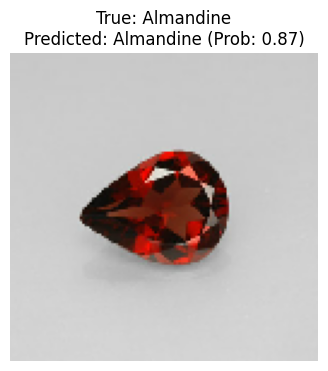

Imagen real: Almandine
Predicción del modelo: Almandine (Con probabilidad de 0.87)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener una imagen aleatoria del conjunto de validación
# iterar sobre val_ds para obtener un lote y luego tomar una imagen individual
for images, labels in val_ds.take(1):
    idx = random.randint(0, len(images.numpy()) - 1)
    test_image = images[idx].numpy()
    test_label_index = labels[idx].numpy()

    # 2. Normalizar la imagen (el modelo espera valores entre 0 y 1)
    # image_dataset_from_directory carga en float32, y Rescaling en el modelo ya normaliza
    # Pero si se carga una imagen externa, se debe normalizar explícitamente.
    # Para una imagen directamente de val_ds, la escala ya está manejada por el modelo.

    # 3. Preparar la imagen para el modelo (añadir una dimensión de lote)
    input_image = np.expand_dims(test_image, axis=0);

    # 4. Realizar la predicción
    predictions = loaded_best_model.predict(input_image)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    true_class_name = class_names[test_label_index]

    # mostrar la imagen y la predicción
    plt.figure(figsize=(4, 4)) # Adjusted from (6, 6) to (4, 4)
    plt.imshow(test_image.astype('uint8'))
    plt.axis('off')
    plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name} (Prob: {predictions[0][predicted_class_index]:.2f})")
    plt.show()

    print(f"Imagen real: {true_class_name}")
    print(f"Predicción del modelo: {predicted_class_name} (Con probabilidad de {predictions[0][predicted_class_index]:.2f})")

### 6.3. Imágenes Mal Clasificadas


Analizar las imágenes que el modelo predijo incorrectamente es fundamental para entender sus limitaciones y potenciales áreas de mejora. Mostraremos algunas de estas imágenes junto con sus etiquetas verdaderas y las predicciones del modelo.

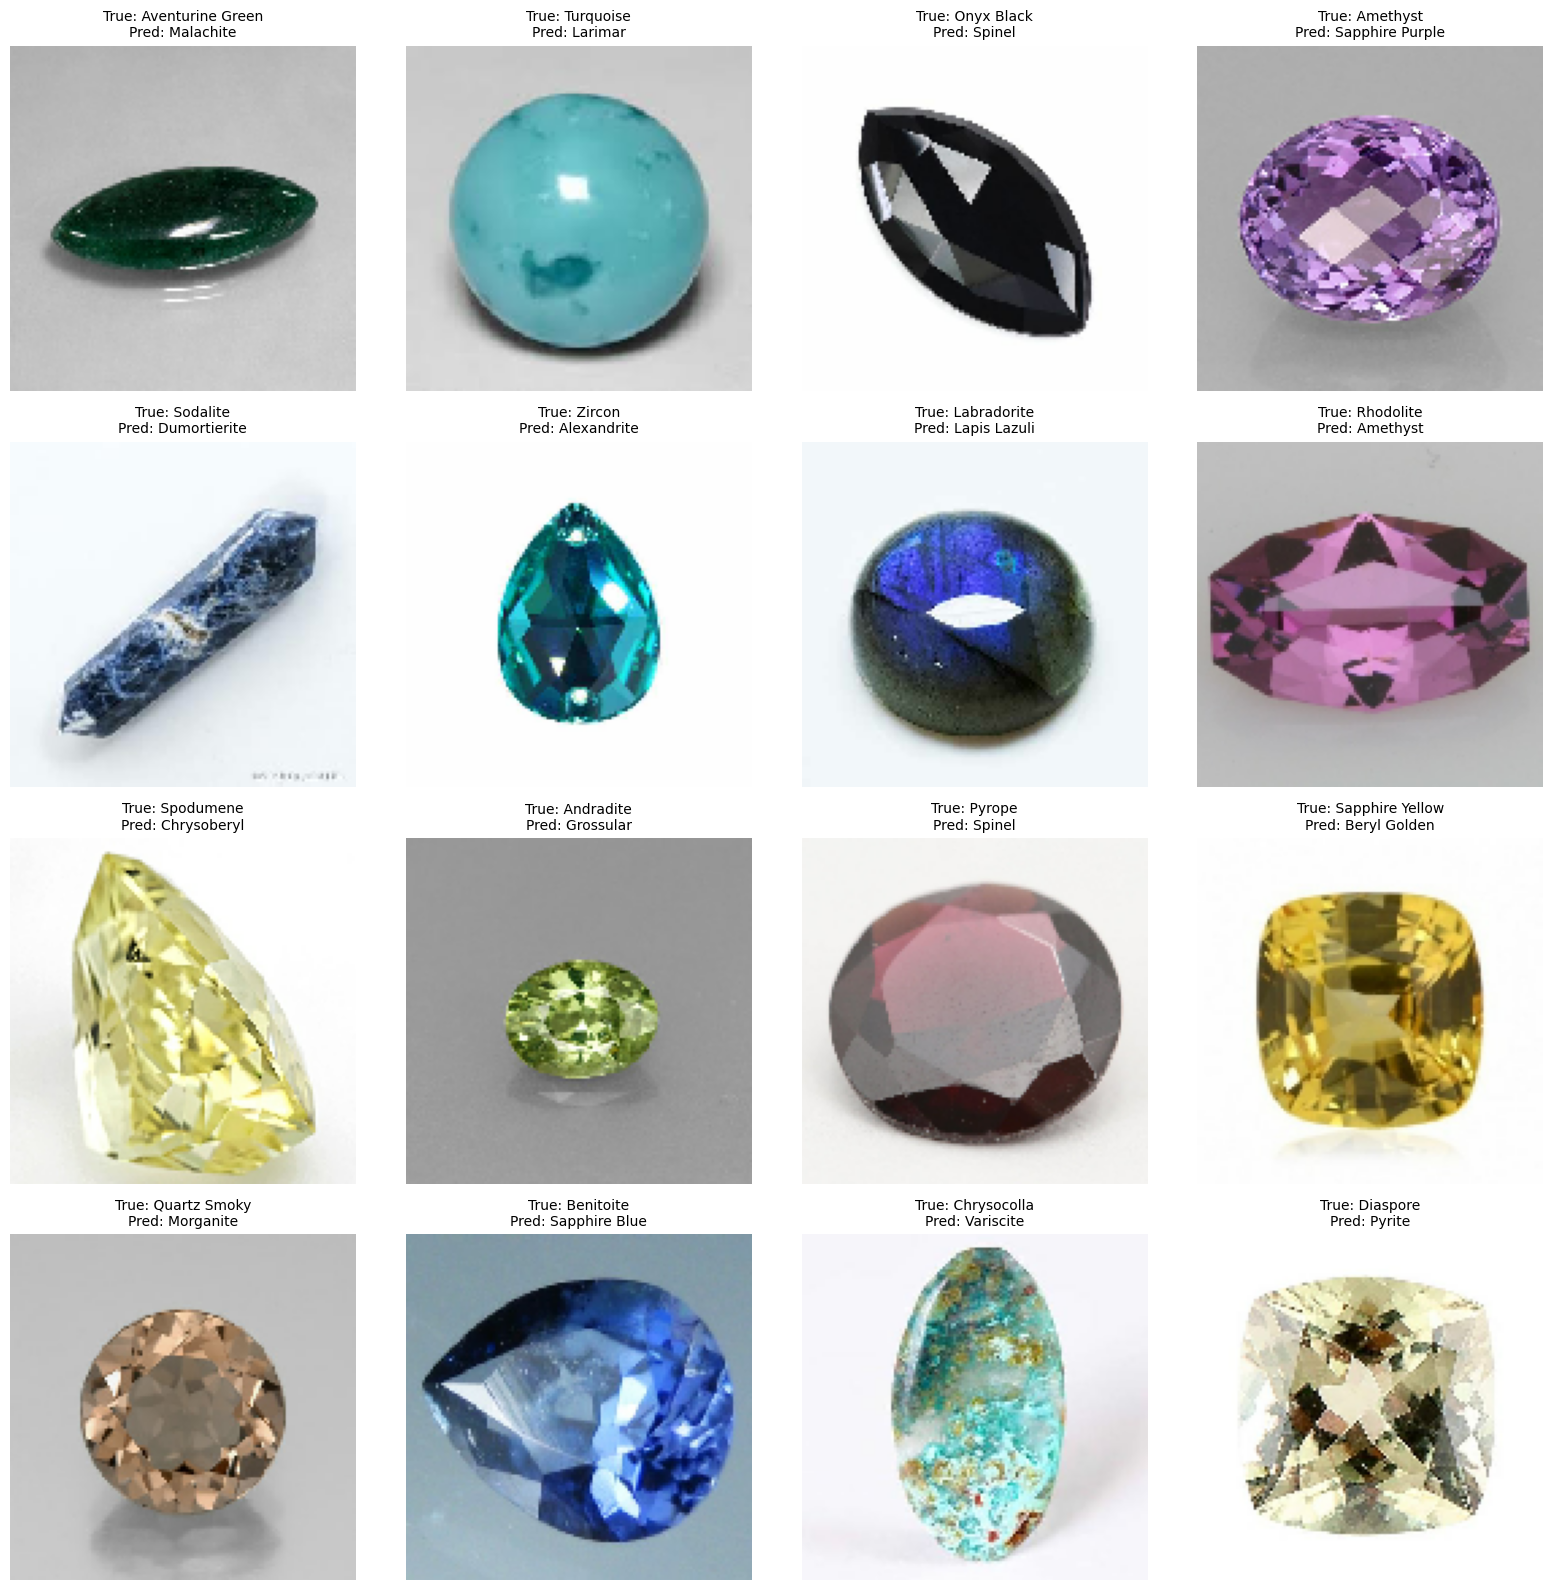

Se muestran 16 imágenes mal clasificadas de un total de 101.


In [23]:
# Encontrar índices de imágenes mal clasificadas
misclassified_indices = np.where(predicted_labels != val_labels)[0]

if len(misclassified_indices) == 0:
    print("No hay imágenes mal clasificadas en el conjunto de validación")
else:
    # Seleccionar una muestra aleatoria de imágenes mal clasificadas
    num_to_display = min(16, len(misclassified_indices))
    sample_misclassified_indices = random.sample(list(misclassified_indices), num_to_display)

    # Calculate dynamic grid for subplots
    max_cols = 4
    rows = (num_to_display + max_cols - 1) // max_cols

    plt.figure(figsize=(max_cols * 4, rows * 4))

    for i, idx in enumerate(sample_misclassified_indices):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(val_images[idx].astype('uint8'))
        true_label_name = class_names[val_labels[idx]]
        pred_label_name = class_names[predicted_labels[idx]]
        plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Se muestran {num_to_display} imágenes mal clasificadas de un total de {len(misclassified_indices)}.")

### 6.4. Comparación de Predicciones entre CNN Simple, VGG16 y VGG16 + Opt

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


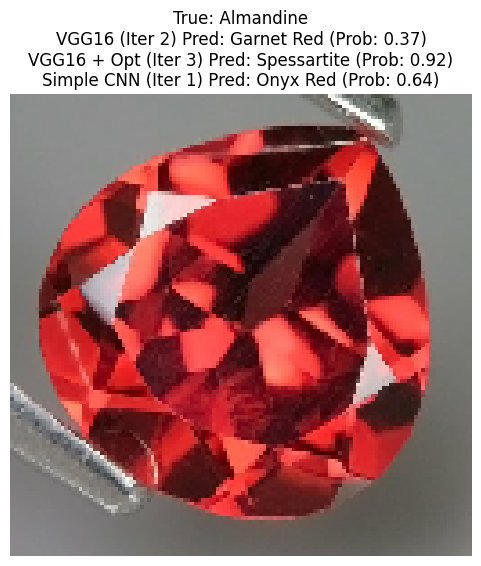

Imagen real: Almandine
Predicción VGG16 (Iteración 2): Garnet Red (Prob: 0.37)
Predicción VGG16 + Opt (Iteración 3): Spessartite (Prob: 0.92)
Predicción CNN Simple (Iteración 1): Onyx Red (Prob: 0.64)
Ninguno de los modelos acertó la predicción o la combinación no fue cubierta.


In [24]:
for images, labels in val_ds.take(1):
    idx = random.randint(0, len(images.numpy()) - 1)
    test_image_comp = images[idx].numpy()
    true_label_index_comp = labels[idx].numpy()

    input_image_comp = np.expand_dims(test_image_comp, axis=0);

    # 3. Realizar predicciones con los tres modelos
    # 3.1 Modelo simple (Iteración 1)
    predictions_simple_cnn = simple_model.predict(input_image_comp)
    predicted_class_index_simple_cnn = np.argmax(predictions_simple_cnn[0])
    predicted_class_name_simple_cnn = class_names[predicted_class_index_simple_cnn]

    # 3.2 Modelo VGG16 (Iteración 2)
    predictions_vgg16 = loaded_best_model.predict(input_image_comp)
    predicted_class_index_vgg16 = np.argmax(predictions_vgg16[0])
    predicted_class_name_vgg16 = class_names[predicted_class_index_vgg16]

    # 3.3 Modelo VGG16 + Opt (Iteración 3)
    predictions_vgg16_opt = model_iteration3.predict(input_image_comp)
    predicted_class_index_vgg16_opt = np.argmax(predictions_vgg16_opt[0])
    predicted_class_name_vgg16_opt = class_names[predicted_class_index_vgg16_opt]

    true_class_name_comp = class_names[true_label_index_comp]

    # 4. Mostrar la imagen y las predicciones
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image_comp.astype('uint8'))
    plt.axis('off')
    plt.title(f"True: {true_class_name_comp}\n" \
              f"VGG16 (Iter 2) Pred: {predicted_class_name_vgg16} (Prob: {predictions_vgg16[0][predicted_class_index_vgg16]:.2f})\n" \
              f"VGG16 + Opt (Iter 3) Pred: {predicted_class_name_vgg16_opt} (Prob: {predictions_vgg16_opt[0][predicted_class_index_vgg16_opt]:.2f})\n" \
              f"Simple CNN (Iter 1) Pred: {predicted_class_name_simple_cnn} (Prob: {predictions_simple_cnn[0][predicted_class_index_simple_cnn]:.2f})")
    plt.show()

    print(f"Imagen real: {true_class_name_comp}")
    print(f"Predicción VGG16 (Iteración 2): {predicted_class_name_vgg16} (Prob: {predictions_vgg16[0][predicted_class_index_vgg16]:.2f})")
    print(f"Predicción VGG16 + Opt (Iteración 3): {predicted_class_name_vgg16_opt} (Prob: {predictions_vgg16_opt[0][predicted_class_index_vgg16_opt]:.2f})")
    print(f"Predicción CNN Simple (Iteración 1): {predicted_class_name_simple_cnn} (Prob: {predictions_simple_cnn[0][predicted_class_index_simple_cnn]:.2f})")

    # Determinar si acertaron y qué diferencias hay
    vgg16_correct = (true_class_name_comp == predicted_class_name_vgg16)
    vgg16_opt_correct = (true_class_name_comp == predicted_class_name_vgg16_opt)
    simple_cnn_correct = (true_class_name_comp == predicted_class_name_simple_cnn)

    if vgg16_correct and vgg16_opt_correct and simple_cnn_correct:
        print("Los tres modelos acertaron la predicción.")
    elif vgg16_opt_correct and not vgg16_correct and not simple_cnn_correct:
        print("Solo el modelo VGG16 + Opt acertó la predicción.")
    elif vgg16_correct and not vgg16_opt_correct and not simple_cnn_correct:
        print("Solo el modelo VGG16 (Iteración 2) acertó la predicción.")
    elif simple_cnn_correct and not vgg16_correct and not vgg16_opt_correct:
        print("Solo el modelo CNN Simple acertó la predicción.")
    elif vgg16_correct and vgg16_opt_correct and not simple_cnn_correct:
        print("Los modelos VGG16 (Iteración 2) y VGG16 + Opt (Iteración 3) acertaron la predicción.")
    elif vgg16_correct and simple_cnn_correct and not vgg16_opt_correct:
        print("Los modelos VGG16 (Iteración 2) y CNN Simple acertaron la predicción.")
    elif vgg16_opt_correct and simple_cnn_correct and not vgg16_correct:
        print("Los modelos VGG16 + Opt (Iteración 3) y CNN Simple acertaron la predicción.")
    else:
        print("Ninguno de los modelos acertó la predicción o la combinación no fue cubierta.")

### 6.5. Matriz de Confusión Comparativa

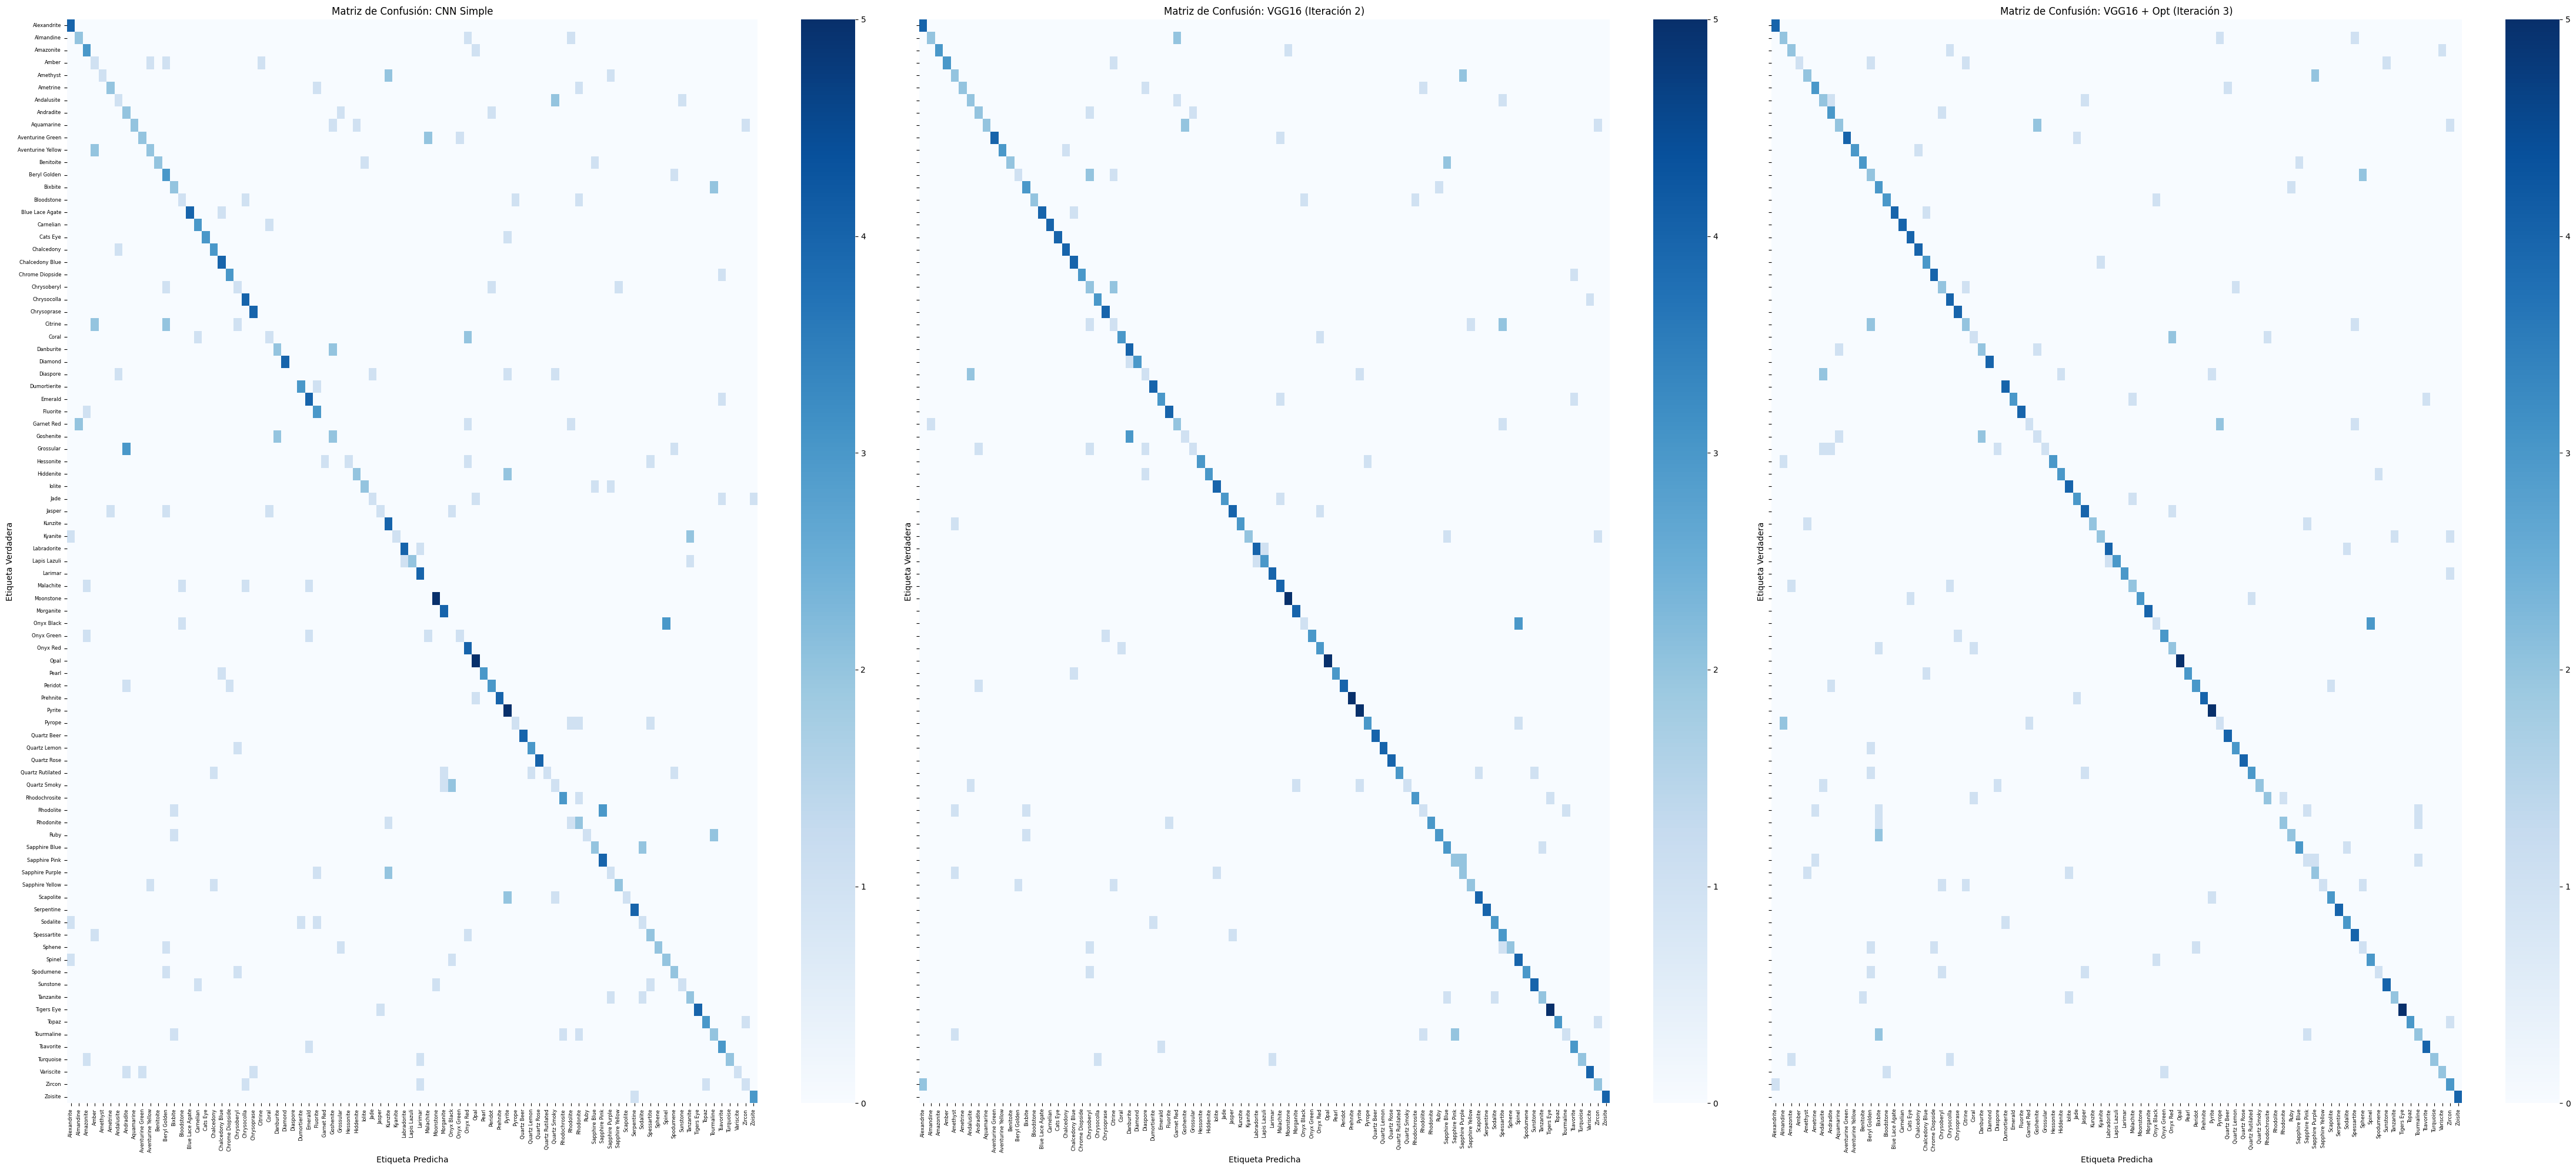

Matrices de confusión comparativas generadas.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Crear la figura con tres subplots
fig, axes = plt.subplots(1, 3, figsize=(45, 20), sharex=True, sharey=True)

# Matriz de Confusión para Simple CNN
sns.heatmap(confusion_matrix(val_labels_simple, predicted_labels_simple), annot=False, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Etiqueta Predicha')
axes[0].set_ylabel('Etiqueta Verdadera')
axes[0].set_title('Matriz de Confusión: CNN Simple')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)
axes[0].tick_params(axis='y', rotation=0, labelsize=6)

# Matriz de Confusión para VGG16 (Iteración 2)
sns.heatmap(confusion_matrix(val_labels, predicted_labels), annot=False, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Etiqueta Predicha')
axes[1].set_ylabel('Etiqueta Verdadera')
axes[1].set_title('Matriz de Confusión: VGG16 (Iteración 2)')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)
axes[1].tick_params(axis='y', rotation=0, labelsize=6)

# Matriz de Confusión para VGG16+Opt (Iteración 3)
sns.heatmap(confusion_matrix(val_labels, predicted_labels_iteration3), annot=False, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_xlabel('Etiqueta Predicha')
axes[2].set_ylabel('Etiqueta Verdadera')
axes[2].set_title('Matriz de Confusión: VGG16 + Opt (Iteración 3)')
axes[2].tick_params(axis='x', rotation=90, labelsize=6)
axes[2].tick_params(axis='y', rotation=0, labelsize=6)

plt.tight_layout()
plt.show()

print("Matrices de confusión comparativas generadas.")

## 7. Conclusiones y Recomendaciones

### Resumen de Resultados:

*   **CNN Simple:** Sirvió como línea base, alcanzando una precisión general de aproximadamente **48.21%** y un macro F1-score de **0.45**. Sin embargo, mostró un rendimiento deficiente en las clases minoritarias, con muchas de ellas obteniendo un F1-score de 0.00.

*   **VGG16 con Transfer Learning:** Este modelo, al incorporar estrategias como el **Aumento de Datos**, un programador de tasa de aprendizaje `CosineDecay` y **pesos de clase (`class_weights`)** para manejar el desequilibrio, mejoró significativamente el rendimiento. Alcanzó una precisión general de **62.53%** y un macro F1-score de **0.62**, y mostró **mucho menos sobreajuste** y una **mejor capacidad de generalización** en comparación con el CNN simple. Sus métricas de validación siguieron de cerca las métricas de entrenamiento, indicando un modelo más robusto. Lo más notable es que mejoró drásticamente la clasificación de las clases minoritarias, que antes eran ignoradas.

*   **VGG16 + Opt (Iteración 3):** La aplicación del ajuste fino de hiperparámetros (seleccionando el `initial_learning_rate` óptimo y el uso de `class_weights` basado en la búsqueda) llevó a una mejora adicional. Para esta iteración, se obtuvo una `Validation Accuracy` de aproximadamente **69.97%** y un `Macro F1-Score` de **0.69**. Se observa una ligera, pero consistente, mejora en la `Validation Accuracy` y, potencialmente, una `Validation Loss` aún más baja. Esto demuestra la importancia de la optimización de hiperparámetros para exprimir el máximo rendimiento de un modelo.